# Uncertainty propagation

Uncertainty is ubiquitous in engineering design. For example, manufacturing processes create deviations from specifications, the system operating and loading conditions may vary, and some parameters are just inherently variable. Furthermore, the engineering models used in the design can be over simplified which introduces uncertainties. All of these can have a direct impact on the engineered system and its performance. Quantifying the impacts of uncertainties on the system is therefore an important part of the engineering design process.

Uncertainty quantification (UQ) is a widely used tool in various science and engineering applications to quantify the impact of uncertainties on model outputs. It consists of three steps: (i) identifying the type of uncertainty in model parameters, (ii) using a mathematical framework to quantify this uncertainty (in most cases, probability theory), and (iii) uncertainty propagation (UP) (also known as forward UQ). The UP consists of propagating randomness in parameters through the model to quantify uncertainty in model output.

This section describes how to perform UP using Monte Carlo simulation (MCS), which involves repeated sampling from the distribution of uncertain input parameters and then computing model output for each sample. These computed model outputs can be used for estimating statistics, such as mean and standard deviation, or to plot the probability distribution of model output. In this way, MCS can be used for propagating uncertainty through the model. Refer to lecture notes for more details.

> __NOTE__: We are using [seaborn](https://seaborn.pydata.org/) for visualizing distributions. It is a very powerful statistical data visualization package in Python. Install seaborn using `pip install seaborn`.

Below code blocks import required packages:

In [15]:
import numpy as np
import seaborn as sns
from pyDOE3 import lhs
import matplotlib.pyplot as plt
from scipy.stats import uniform
from scipy.stats.qmc import Halton

## MCS

In this section, MCS is demonstrated using ishigami function which is written as

$$
    f(\mathbf{x}) = \sin(x_1) + 7\sin^2(x_2) + 0.05 x_3^4 \sin(x_1).
$$

Each input variable follows a uniform distribution which is written as 

$$
    X_i \sim \mathbb{U}[-\pi,\pi], \forall \text{ } i = 1,2,3. 
$$

Due to this uncertainty in input parameters, output of the ishigami function is uncertain. So, the goal here is to quantify this uncertainty in function output.

Below code block defines ishigami function:

In [28]:
def ishigami(x):

    x = np.atleast_2d(x)

    return np.sin(x[:,0]) + 7*np.sin(x[:,1])**2 + 0.1*x[:,2]**4 * np.sin(x[:,0])

### Define random variables

Below code block defines uniform random variable (rv) for each input parameter. We are using `uniform` class from `scipy.stats` for defining rv. The two primary inputs to this class are - `loc` and `scale`. The `loc` argument defines the starting point of the specified range while the `scale` argument refers to the range itself. For example, if you want to define a uniform rv with a range of [2,5], then you need to define `loc=2` and `scale=3`. You can read more about `uniform` class [here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.uniform.html). You can also create a normally distributed variable using [`norm`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html) class from `scipy.stats`, refer [here](https://docs.scipy.org/doc/scipy/reference/stats.html#continuous-distributions) for the full list of distributions.

In [3]:
# Defining random variables
rv_x1 = uniform(loc=-np.pi, scale=2*np.pi)
rv_x2 = uniform(loc=-np.pi, scale=2*np.pi)
rv_x3 = uniform(loc=-np.pi, scale=2*np.pi)

### Propagation

Once random variables are defined, next step is to draw samples from the input parameter distribution and compute the value of function for each sample.

> __NOTE__: You can also just define a single uniform random variable and generate samples with `size=(N_samples,3)`

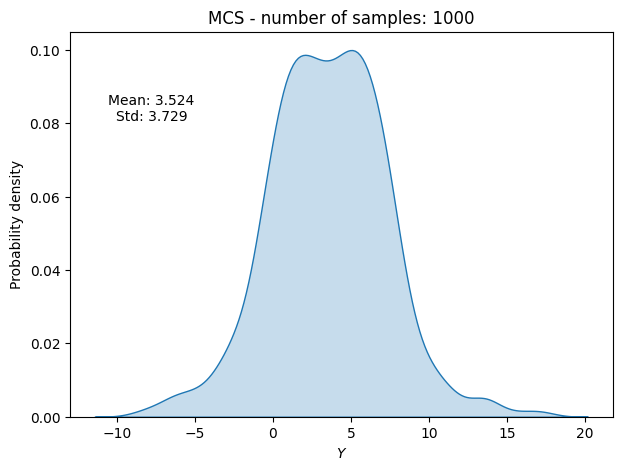

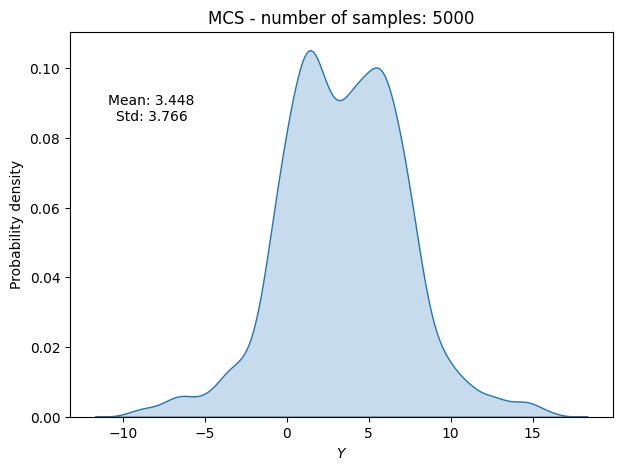

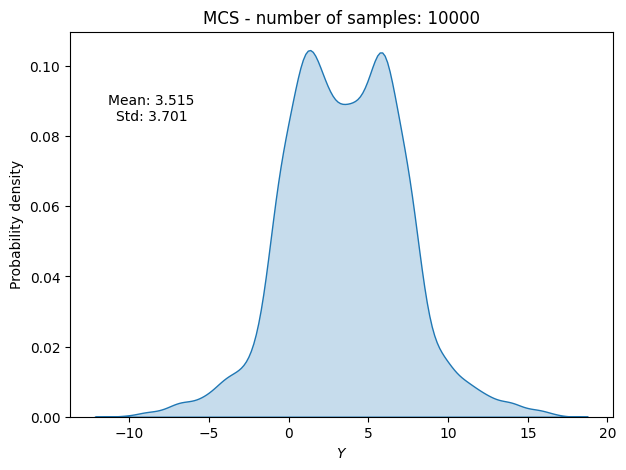

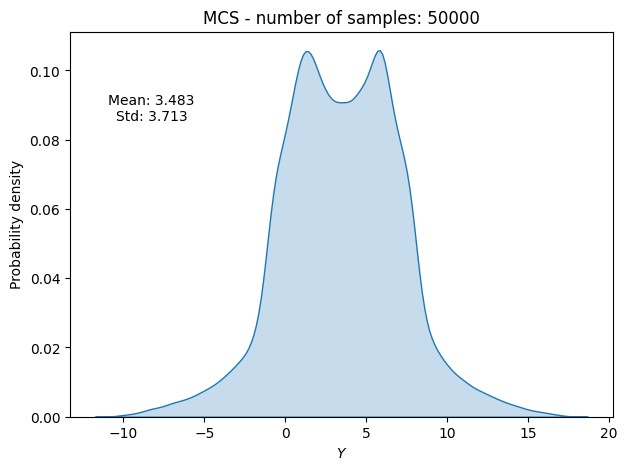

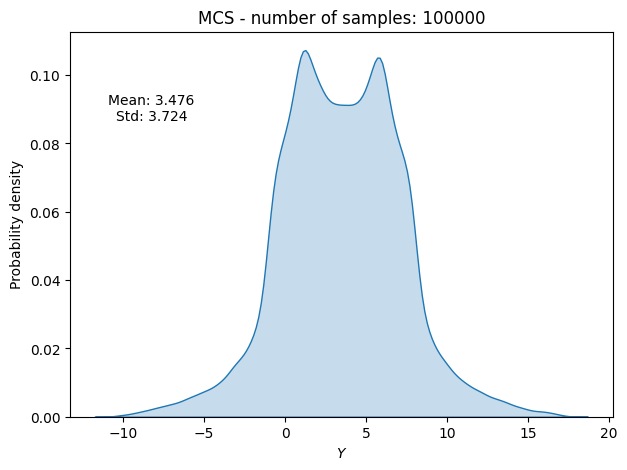

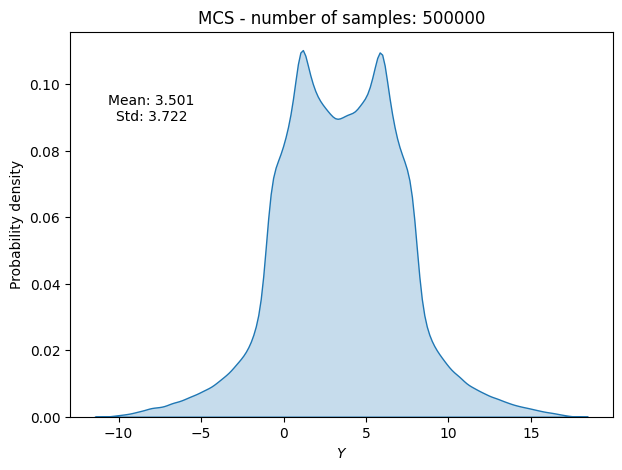

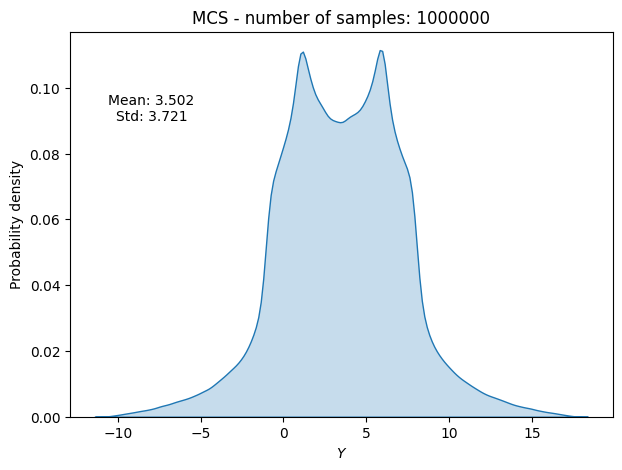

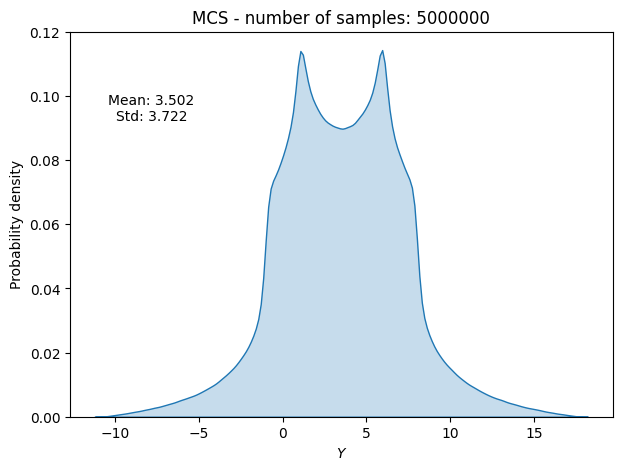

In [40]:
# number of samples
samples = [1000, 5000, 10000, 50000, 100000, 500000, 1000000, 5000000]

# empty list to store results
mean_random = []
std_random = []

# Loop through each sample size
for sample in samples:

    # randomly drawn samples
    x_samples = np.hstack((
        rv_x1.rvs(size=sample).reshape(-1,1),
        rv_x2.rvs(size=sample).reshape(-1,1),
        rv_x3.rvs(size=sample).reshape(-1,1),
    ))

    # evaluate function at the samples
    f_values = ishigami(x_samples)

    # compute statistics
    mean_random.append(np.mean(f_values))
    std_random.append(np.std(f_values))

    # Plot PDF of function output
    fig, ax = plt.subplots(figsize=(7,5))
    sns.kdeplot(x=f_values, fill=True, ax=ax)
    ax.set_ylabel("Probability density")
    ax.set_xlabel("$Y$")
    ax.set_title("MCS - number of samples: {}".format(sample))
    ax.annotate(f"Mean: {mean_random[-1]:.3f}\nStd: {std_random[-1]:.3f}", xy=(0.15, 0.8), xycoords="axes fraction", va="center", ha="center")

### Convergence

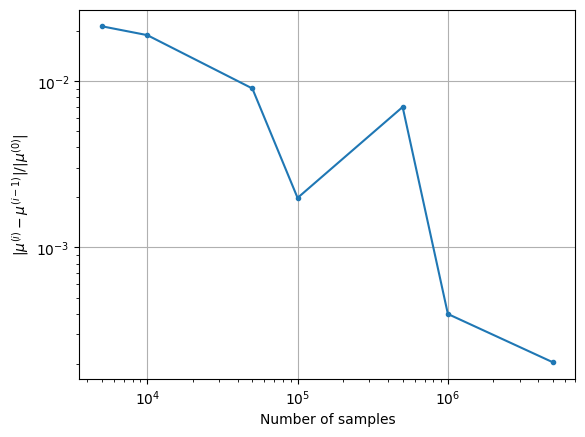

In [41]:
conv_mean_random = np.abs(np.diff(mean_random)/mean_random[0])

fig, ax = plt.subplots()
ax.plot(samples[1:], conv_mean_random, marker=".")
ax.grid()
ax.set_ylabel(r"$ |\mu^{(i)} - \mu^{(i-1)}| / |\mu^{(0)}|$")
ax.set_xlabel("Number of samples")
ax.set_xscale("log")
ax.set_yscale("log")

It takes large number of samples - not possible when each function evaluation is expensive.

So, you need to create a surrogate model to approximate true function and then do UP.